In [206]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.utils import to_categorical
import random
!pip install np_utils


In [207]:
np.random.seed(0)

(X_train , y_train) , (X_test , y_test) = mnist.load_data()

In [ ]:
num_of_samples = []
cols=5
num_classes=10

# fig,axs = plt.subplots(nrows = num_classes , ncols = cols ,figsize=(5,10) )
# fig.tight_layout()

In [209]:
# num_of_samples = []
# cols=5
# num_classes=10

# fig,axs = plt.subplots(nrows = num_classes , ncols = cols ,figsize=(5,10) )
# fig.tight_layout()
# for i in range(cols):
#     for j in range(num_classes):
#         x_selected = X_train[y_train==j]
#         axs[j][i].imshow(x_selected[random.randint(0 , len(x_selected)-1) , : , :] , cmap = plt.get_cmap('gray'))
#         axs[j][i].axis('off')
#         if i==2:
#             axs[j][i].set_title(str(j))
#             num_of_samples.append(len(x_selected))
# print(num_of_samples)



In [210]:
y_train = to_categorical(y_train , 10)
y_test = to_categorical(y_test , 10)

In [211]:
X_train = X_train/255
X_test = X_test/255

num_pixels = 784
X_train = X_train.reshape(X_train.shape[0] , num_pixels)
X_test = X_test.reshape(X_test.shape[0] , num_pixels)


In [212]:
def create_model():
    model = Sequential()
    model.add(Dense(5 , input_dim = num_pixels , activation='relu'))
    model.add(Dense(30 , activation='relu'))
    model.add(Dense(10 , activation='relu'))
    model.add(Dense(num_classes , activation='softmax'))
    adam = Adam(learning_rate=0.01)
    model.compile(adam , loss='categorical_crossentropy' , metrics=['accuracy'])
    return model

In [213]:
model = create_model()
print(model.summary(0))

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 5)              │         3,925 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 30)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,525 (17.68 KB)

 Trainable params: 4,525 (17.68 KB)

 Non-trainable params: 0 (0.00 B)

None


In [197]:
history = model.fit(X_train , y_train , validation_split=0.1 , epochs=15 , batch_size=200 , verbose=1 , shuffle=True)

Epoch 1/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6524 - loss: 1.0282 - val_accuracy: 0.8920 - val_loss: 0.3678
Epoch 2/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8775 - loss: 0.4132 - val_accuracy: 0.9020 - val_loss: 0.3351
Epoch 3/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8909 - loss: 0.3656 - val_accuracy: 0.9168 - val_loss: 0.2891
Epoch 4/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8993 - loss: 0.3419 - val_accuracy: 0.9143 - val_loss: 0.2944
Epoch 5/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9039 - loss: 0.3260 - val_accuracy: 0.9197 - val_loss: 0.2761
Epoch 6/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9058 - loss: 0.3153 - val_accuracy: 0.9205 - val_loss: 0.2761
Epoch 7/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9070 - loss: 0.3160 - val_accuracy: 0.9145 - val_loss: 0.2996
Epoch 8/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9094 - loss: 0.3076 - val_accuracy: 0.

Text(0.5, 0, 'epoch')

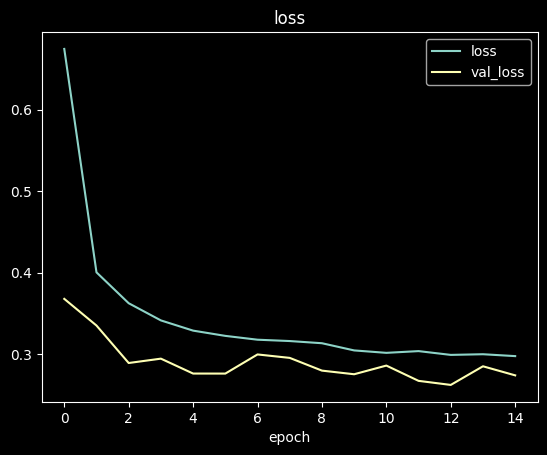

In [198]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss' , 'val_loss'])
plt.title('loss')
plt.xlabel('epoch')

Text(0.5, 0, 'epoch')

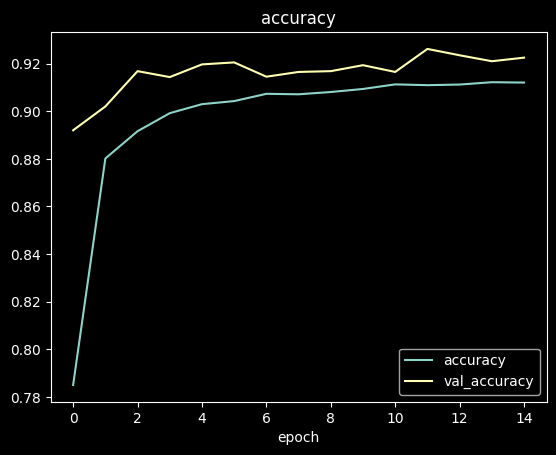

In [199]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['accuracy' , 'val_accuracy'])
plt.title('accuracy')
plt.xlabel('epoch')

(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

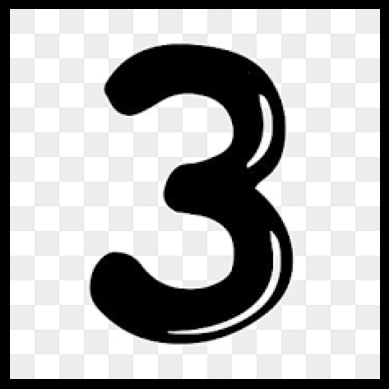

In [200]:
import cv2
img = cv2.imread('3.png')
plt.imshow(img)
plt.axis('off')
 

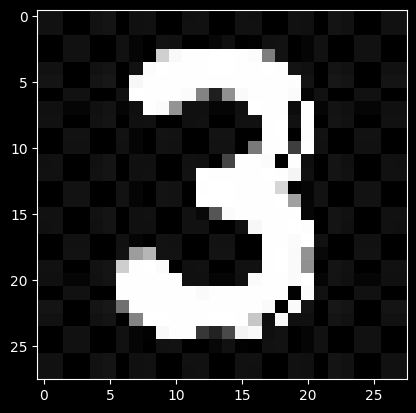

In [201]:
img = cv2.resize(img , (28,28))               
img = cv2.cvtColor(img , cv2.COLOR_BGR2GRAY)    
img = cv2.bitwise_not(img) 
plt.imshow(img , cmap='gray')


In [202]:
img = img/255
img.shape

img = img.reshape(1,784)

In [203]:
prediction = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


In [204]:
prediction

array([[3.1614173e-14, 7.8794917e-09, 2.3281509e-06, 9.9998844e-01,
        6.0748001e-16, 9.1142620e-06, 7.5125028e-12, 9.4457651e-09,
        1.0993999e-08, 3.7071420e-14]], dtype=float32)

In [205]:
predicted_label = np.argmax(prediction)
predicted_label

np.int64(3)